In [2]:
import torch
import matplotlib.pyplot as plt

In [3]:
import os
import pathlib
import pickle

path = pathlib.Path('/u/rfechner/out/entropy_logging/Qwen/Qwen2.5-1.5B_entropy_0.0_kl_0.0/entropy_dumps')
dumps = {}
for file in path.iterdir():
    if file.is_file() and file.name.endswith('.pickle'):
        step = file.name.split('-')[1].replace('.pickle', '')
        with open(file, 'rb') as io:
            dumps[str(step)] = pickle.load(io)
advs = [s['advantages'] for s in dumps.values()]
entropies = [s['deltas'] for s in dumps.values()]

### Advantage and entropy analysis

First of all, I'd like to plot the number of effective trajectories over time. An effective trajectory is
has non-zero advantage.

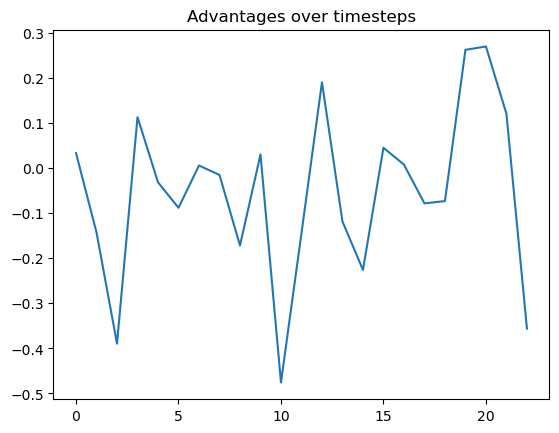

In [4]:
plt.plot([ad[ad != 0].mean() for ad in advs])
plt.title('Advantages over timesteps')
plt.show()

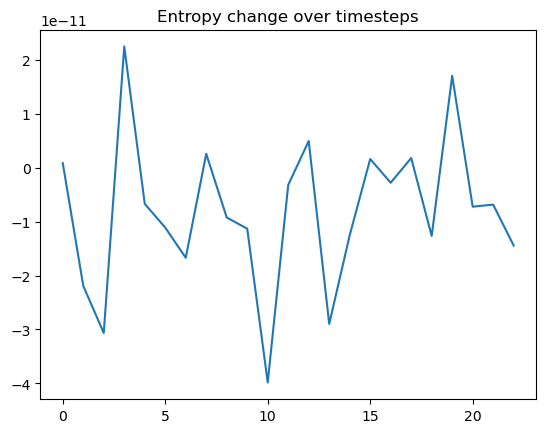

In [5]:
plt.plot([ent[ent != 0].mean() for ent in entropies])
plt.title('Entropy change over timesteps')
plt.show()

### Observation: mean change in entropy and mean advantage correlate

Shouldn't the reltationship be inversely proportional? When the advantage is high we should measure a decrease in entropy. Perhaps I've got a sign error?


In [ ]:
import pandas as pd

In [12]:
# look at regular entropy
metrics_path = path.parent / 'metrics.jsonl'
metrics = pd.read_json(metrics_path, lines=True)

In [14]:
metrics[['step', 'actor/entropy']]

,step,actor/entropy
0,1,2.524463
1,2,2.939239
2,3,2.835016
3,4,2.554817
4,5,2.465695
5,6,2.962023
6,7,2.712039
7,8,2.733719
8,9,2.425247
9,10,2.700190


In [15]:
# entropy doesn't seem to decline as drastically as in other trainin setups. -> Re-check 7b GRPO run.
metrics_7b = pd.read_json('/u/rfechner/out/fixed/Qwen/Qwen2.5-7B_entropy_0.0_kl_0.001_20250808_130226/metrics.jsonl', lines=True)
metrics_7b[['step', 'actor/entropy']]

,step,actor/entropy
0,1,0.549513
1,2,0.619969
2,3,0.469929
3,4,0.372397
4,5,0.315255
...,...,...
74,75,0.067553
75,76,0.062132
76,77,0.063500
77,78,0.070116


### Observation

It seems that the starting entropy in the generations in the 1.5B and the 7B model are quite different. The 7B model has way lower entropy to spare. 

### Validation: Do entropy change and predicted entropy change correlate?

In [31]:
import numpy as np
true_entropy = metrics['actor/entropy'].to_numpy()
true_entropy_diffs = np.diff(true_entropy)
pred_entropy_diffs = np.array([ent[ent != 0].mean() for ent in entropies])
advantages = np.array([ad[ad != 0].mean() for ad in advs])

true_entropy_diffs = (true_entropy_diffs - true_entropy_diffs.mean()) / true_entropy_diffs.std()
pred_entropy_diffs = (pred_entropy_diffs - pred_entropy_diffs.mean()) / pred_entropy_diffs.std()
pred_entropy_diffs = pred_entropy_diffs[:-1]

advantages = (advantages - advantages.mean()) / advantages.std()
advantages = advantages[:-1]

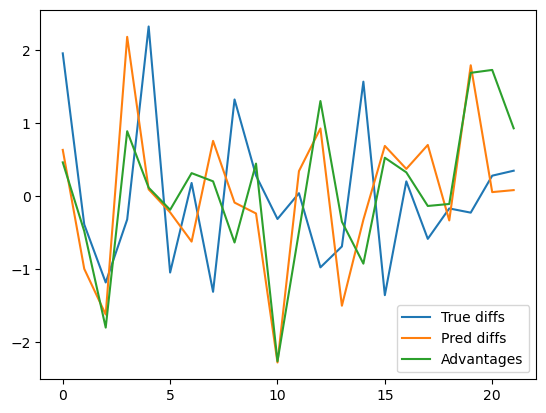

In [32]:
plt.plot(true_entropy_diffs, label='True diffs')
plt.plot(pred_entropy_diffs, label='Pred diffs')
plt.plot(advantages, label='Advantages')
plt.legend()
plt.show()

In [34]:
((true_entropy_diffs * pred_entropy_diffs) > 0).sum() / true_entropy_diffs.shape[0]

np.float64(0.5454545454545454)

### Observation

It seems like we cannot predict the sign of the entropy update... Also: accuracy seems to get worse over time...

*Possible reasons*
    
- The bias in the advantage computation also biases my entropy prediction. Could try to just take the sign of the advantage instead.
- We have to instead of taking the aggregated entropy, look at the entropy change at each token index over time.
- We're working with a first order approximation, and have to increase the APPROX_K for better results
    - This is something we might be able to verify experimentally. How does APPROX_K impact accuracy? 


### Experimental verification

- we'll try to understand the impact of sub-sampling the logits for top-k instead of the full distribution. In my experiments, vocab size is 150k and APPROX_K=100. This
should in most cases capture most of the probability mass of the distribution... however we have to verify that.

In [43]:
import matplotlib.pyplot as plt
from tqdm import tqdm

  0%|          | 0/90 [00:00<?, ?it/s]

100%|██████████| 90/90 [00:42<00:00,  2.11it/s]


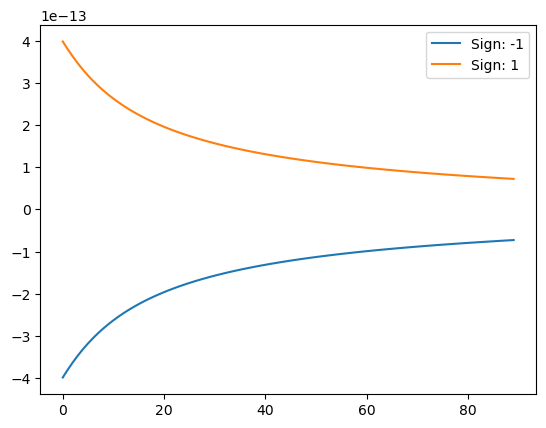

In [45]:
APPROX_K = range(10, 100)
logits = torch.randn(size=(100, 128, 100))

def entropy_from_logits(logits: torch.Tensor):
    """Calculate entropy from logits.
        TODO: This copies the logits, which are quite large ~48GB over 4GPUs = 12.17GiB per GPU.
        We're just trying to get the entropy and do currently not care about keeping tracks of gradients.
        Could we instead unroll this operation to reduce peak memory consumption?

        Recipe: iterate over sequence length axis:
            chunksize 64, compute the statistics, then allocate into a list.
    """
    CHUNKSIZE=64
    entropy_accu = []

    for i in range(0, logits.shape[1], CHUNKSIZE):
        batch = logits[:, i:i+CHUNKSIZE, :]
        pd = torch.nn.functional.softmax(batch, dim=-1)
        entropy = torch.logsumexp(batch, dim=-1) - torch.sum(pd * batch, dim=-1)
        entropy_accu.append(entropy)

    return torch.concatenate(entropy_accu, dim=1)
entropy = entropy_from_logits(logits)

for sign in [-1, 1]:
    deltas = []
    for approx_k in tqdm(APPROX_K):
        topk_logits, topk_indices = torch.topk(input=logits, k=approx_k, dim=-1)  # (B, L, K), (B, L, K)

        # 3) Recompute probs over the augmented top-k
        topk_log_probs = torch.nn.functional.log_softmax(topk_logits, dim=-1)         # (B, L, K)
        topk_probs = topk_log_probs.exp()                                             # (B, L, K)

        # 4) Entropy gradient term (∂H/∂z) restricted to top-k
        # entropy: (B, L)
        dH_dz = topk_probs * (topk_log_probs - entropy.unsqueeze(-1))                 # (B, L, K)
        dL_dz = torch.concat([
            torch.full(size=(*logits.shape[:2], 1),             fill_value= sign * 1e-6),
            torch.full(size=(*logits.shape[:2], approx_k - 1),  fill_value= -sign * 1e-6)
        ], dim=-1)
        delta = (dH_dz * dL_dz * 1e-6).mean()
        deltas.append(delta)
    plt.plot(deltas, label=f'Sign: {sign}')
plt.legend()
plt.show()

#### Interpretations

Likely, the effects of increasing the APPROX_K will just scale the gradients. We see diminishing returns, as the largest logit dominates the softmax anyways and
incorporating more logits yields diminishing returns.


In [28]:
import torch
import matplotlib.pyplot as plt
import pathlib
import pickle

"""
    I've re-run the experiments with bugfixes:
        - sign error in the entropy gradient calculation:

        The entropy at position $t$ is:
        \[
        \mathcal{H}_t = - \sum_v \pi(y_v) \log \pi(y_v).
        \]

        Its derivative w.r.t. a logit $z_v$ is:
        \[
        \frac{\partial \mathcal{H}_t}{\partial z_v} = -\pi(y_v) \Bigl( \log \pi(y_v) + \mathcal{H}_t \Bigr).
        \]
        which was (incorrectly):
        \[
        \frac{\partial \mathcal{H}_t}{\partial z_v} = -\pi(y_v) \Bigl( \log \pi(y_v) - \mathcal{H}_t \Bigr).
        \]
"""
path = pathlib.Path('/u/rfechner/out/entropy_logging/SUBSET_Qwen/Qwen2.5-1.5B_entropy_0.0_kl_0.0_20250821_140649/entropy_dumps')
dumps = {}
for file in path.iterdir():
    if file.is_file() and file.name.endswith('.pickle'):
        step = file.name.split('-')[1].replace('.pickle', '')
        with open(file, 'rb') as io:
            dumps[str(step)] = pickle.load(io)
advs = [s['advantages'] for s in dumps.values()]
entropies = [s['deltas'] for s in dumps.values()]

In [29]:
import pandas as pd

In [30]:
# look at regular entropy
metrics_path = path.parent / 'metrics.jsonl'
metrics = pd.read_json(metrics_path, lines=True)

In [40]:
import numpy as np
true_entropy = metrics['actor/entropy'].to_numpy()
true_entropy_diffs = np.diff(true_entropy)
pred_entropy_diffs = np.array([ent[ent != 0].mean() for ent in entropies])
advantages = np.array([ad[ad != 0].mean() for ad in advs])

In [37]:
true_entropy_diffs = (true_entropy_diffs - true_entropy_diffs.mean()) / true_entropy_diffs.std()
pred_entropy_diffs = (pred_entropy_diffs - pred_entropy_diffs.mean()) / pred_entropy_diffs.std()
pred_entropy_diffs = pred_entropy_diffs[:-1] * -1

advantages = (advantages - advantages.mean()) / advantages.std()
advantages = advantages[:-1]

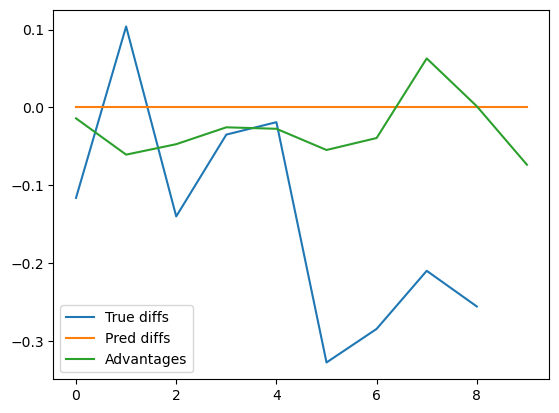

In [41]:
plt.plot(true_entropy_diffs, label='True diffs')
plt.plot(pred_entropy_diffs, label='Pred diffs')
plt.plot(advantages, label='Advantages')
plt.legend()
plt.show()

In [19]:
((true_entropy_diffs * pred_entropy_diffs) > 0).sum() / true_entropy_diffs.shape[0]

np.float64(0.6363636363636364)

In [42]:
advantages

array([-0.01404155, -0.06064369, -0.04721451, -0.02554083, -0.02741974,
       -0.05466448, -0.03928734,  0.06295799,  0.00149864, -0.07355742],
      dtype=float32)